# 05 -- Model comparison

This notebook pulls together every model from notebooks 02-04 -- baseline
CNN, ResNet-18, EfficientNet-B0 and the AST linear probe, plus the full
AST fine-tune -- and compares them on equal footing: same test set, same
metrics, same split.

**The five full-scale results already ship with this repo**, so every
cell below works on a fresh clone with no training required. They were
trained from the `configs/gpu/` variants on a single rented RTX 4090
(~2 hours for all five, well under $1 -- see `docs/runpod_run.md`), and
their metrics live in `results/metrics/*_gpu_eval.json`.

`RUN_NAMES` below also lists the bare `configs/` run names
(`baseline_cnn`, `resnet18`, ...). Those are the CPU-sized configs, and
they are *not* shipped -- train them yourself if you want them, and they
will appear in the tables alongside the GPU runs:

```
python -m watkins.train --config configs/baseline_cnn.yaml
python -m watkins.train --config configs/resnet18.yaml
python -m watkins.train --config configs/efficientnet_b0.yaml
python -m watkins.train --config configs/ast_linear_probe.yaml
python -m watkins.evaluate --checkpoint results/checkpoints/<run_name>_best.pt
python -m watkins.robustness --checkpoint results/checkpoints/<run_name>_best.pt
```

Any run name with no metrics file is skipped with a message telling you
which command produces it, so nothing breaks either way. The notebooks'
fast `*_demo` runs are deliberately left out of `RUN_NAMES` -- a
5-epoch, 30%-subset demo has no business sitting in a comparison table
next to a full-scale result.

In [1]:
import os
import subprocess
import sys
import importlib.util

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # 1. Mount Drive and locate the project. Upload src/, configs/,
    #    pyproject.toml, requirements.txt to this path in My Drive first --
    #    NOT the multi-GB Watkins/ or results/ folders, those are handled
    #    separately below.
    from google.colab import drive
    drive.mount("/content/drive")

    PROJECT_DRIVE_PATH = "/content/drive/MyDrive/MarineMammals"  # <-- edit if you used a different path
    if not os.path.exists(f"{PROJECT_DRIVE_PATH}/src/watkins"):
        raise FileNotFoundError(
            f"Expected the project's src/ folder at {PROJECT_DRIVE_PATH}/src on Google Drive.\n"
            "Upload src/, configs/, pyproject.toml, and requirements.txt there "
            "(skip the multi-GB Watkins/ and results/ folders), or edit "
            "PROJECT_DRIVE_PATH above to match where you put them."
        )
    sys.path.insert(0, f"{PROJECT_DRIVE_PATH}/src")

    # 2. Install whatever Colab's base image doesn't already have. Deliberately
    #    does NOT touch torch/torchaudio/torchvision -- Colab's preinstalled
    #    versions are already matched to its GPU + CUDA build, and reinstalling
    #    this project's CPU-only wheels here would silently disable the GPU.
    needed = ["transformers", "timm", "soundfile", "datasets", "huggingface_hub", "pyarrow"]
    missing = [pkg for pkg in needed if importlib.util.find_spec(pkg) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

    # 3. Data goes on fast local/ephemeral disk (re-derivable from the public
    #    Hugging Face source, no reason to pay Drive's slow random-I/O tax on
    #    thousands of per-epoch file reads); results go on Drive so trained
    #    checkpoints/metrics survive a runtime disconnect.
    os.environ["WATKINS_DATA_ROOT"] = "/content/watkins_data"
    os.environ["WATKINS_RESULTS_ROOT"] = f"{PROJECT_DRIVE_PATH}/results"

    from watkins.data import DATA_ROOT
    if not (DATA_ROOT / "manifest.csv").exists():
        print("Materializing the Watkins dataset locally -- one-time per Colab runtime, ~10-15 min...")
        subprocess.run([sys.executable, "-m", "watkins.prepare_data"], check=True)
else:
    sys.path.insert(0, "../src")

import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from watkins.data import CLASS_IDS, CLASS_INFO
from watkins.models import build_model
from watkins.utils import count_parameters, results_root

RESULTS = results_root()
RUN_NAMES = [
    # CPU-sized configs/ runs, then the scaled-up configs/gpu/ runs. Missing
    # entries are skipped with a message, so this list can name more runs than
    # you have actually trained.
    "baseline_cnn", "resnet18", "efficientnet_b0", "ast_linear_probe",
    "baseline_cnn_gpu", "resnet18_gpu", "efficientnet_b0_gpu",
    "ast_linear_probe_gpu", "ast_finetune_gpu",
]


def _arch(run_name):
    """Run name -> the architecture key build_model() expects.

    Only needed here to count parameters. Both AST runs (linear probe and
    full fine-tune) are the same 86M-parameter architecture; they differ in
    what was trainable, not in shape."""
    base = run_name.removesuffix("_gpu")
    return "ast" if base.startswith("ast") else base


MODEL_KEY = {r: _arch(r) for r in RUN_NAMES}


/home/kj/Documents/CodeProjects/MarineMammals/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Headline comparison table: accuracy, macro-F1, and parameter budget

Macro-F1 (unweighted average of per-class F1) matters more than accuracy
here -- recall the severe long-tail imbalance from notebook 00 (killer
whale alone is ~28% of all clips). A model that leans on the two or three
biggest species can post decent accuracy while doing badly on the ~50
species you'd actually care about identifying reliably.

In [2]:
rows = []
for run_name in RUN_NAMES:
    metrics_path = RESULTS / "metrics" / f"{run_name}_eval.json"
    if not metrics_path.exists():
        print(f"missing: {metrics_path} -- run `python -m watkins.evaluate --checkpoint "
              f"results/checkpoints/{run_name}_best.pt` first")
        continue
    with open(metrics_path) as f:
        m = json.load(f)
    model, _ = build_model(MODEL_KEY[run_name], num_classes=54)
    rows.append(dict(
        model=run_name,
        accuracy=m["accuracy"],
        macro_f1=m["macro_f1"],
        weighted_f1=m["weighted_f1"],
        params=count_parameters(model),
    ))

comparison = pd.DataFrame(rows, columns=["model", "accuracy", "macro_f1", "weighted_f1", "params"]).set_index("model")
comparison


missing: /home/kj/Documents/CodeProjects/MarineMammals/results/metrics/baseline_cnn_eval.json -- run `python -m watkins.evaluate --checkpoint results/checkpoints/baseline_cnn_best.pt` first
missing: /home/kj/Documents/CodeProjects/MarineMammals/results/metrics/resnet18_eval.json -- run `python -m watkins.evaluate --checkpoint results/checkpoints/resnet18_best.pt` first
missing: /home/kj/Documents/CodeProjects/MarineMammals/results/metrics/efficientnet_b0_eval.json -- run `python -m watkins.evaluate --checkpoint results/checkpoints/efficientnet_b0_best.pt` first
missing: /home/kj/Documents/CodeProjects/MarineMammals/results/metrics/ast_linear_probe_eval.json -- run `python -m watkins.evaluate --checkpoint results/checkpoints/ast_linear_probe_best.pt` first


[transformers] You passed `num_labels=54` which is incompatible to the `id2label` map of length `527`.


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 203/203 [00:00<00:00, 2355.28it/s]


[transformers] ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                          
------------------------+----------+------------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([54, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([54])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


[transformers] You passed `num_labels=54` which is incompatible to the `id2label` map of length `527`.


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 203/203 [00:00<00:00, 3525.18it/s]


[transformers] ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                          
------------------------+----------+------------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([54, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([54])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


,accuracy,macro_f1,weighted_f1,params
model,,,,
baseline_cnn_gpu,0.446615,0.292782,0.427621,402678
resnet18_gpu,0.485352,0.296074,0.464058,11204214
efficientnet_b0_gpu,0.503581,0.356700,0.488248,4076722
ast_linear_probe_gpu,0.506836,0.307746,0.463147,86230326
ast_finetune_gpu,0.576497,0.358433,0.504147,86230326


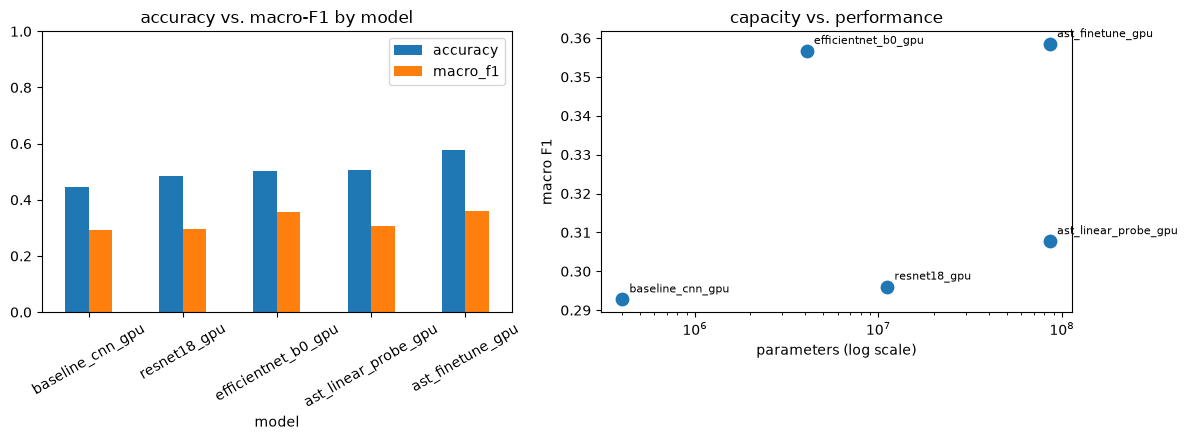

In [3]:
if comparison.empty:
    print("No evaluated checkpoints yet -- run the commands printed above first.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    comparison[["accuracy", "macro_f1"]].plot(kind="bar", ax=axes[0])
    axes[0].set_ylim(0, 1)
    axes[0].set_title("accuracy vs. macro-F1 by model")
    axes[0].tick_params(axis="x", rotation=30)

    axes[1].scatter(comparison["params"], comparison["macro_f1"], s=80)
    for name, row in comparison.iterrows():
        axes[1].annotate(name, (row["params"], row["macro_f1"]), fontsize=8,
                          xytext=(5, 5), textcoords="offset points")
    axes[1].set_xscale("log")
    axes[1].set_xlabel("parameters (log scale)")
    axes[1].set_ylabel("macro F1")
    axes[1].set_title("capacity vs. performance")
    plt.tight_layout()
    plt.show()


Look at the second plot in particular: does more capacity actually buy
more accuracy on ~15,000 clips spread over 54 imbalanced species, or does
it plateau (or worse, dip once overfitting sets in)? That answer is
dataset-size-dependent, not a fact about any architecture in the
abstract -- it's the answer *for this dataset*.

## 2. Per-class F1: where does each architecture actually struggle?

`results/SUMMARY.md` (regenerated by `python -m watkins.summarize`) shows
this same table for the best-represented species, in markdown form.

In [4]:
first_metrics_path = next((RESULTS / "metrics" / f"{r}_eval.json" for r in RUN_NAMES
                            if (RESULTS / "metrics" / f"{r}_eval.json").exists()), None)
top_species = []
if first_metrics_path is not None:
    with open(first_metrics_path) as f:
        m0 = json.load(f)
    # Drop sklearn's summary rows before ranking by support. Note "micro avg":
    # classification_report emits it in place of "accuracy" whenever it's given
    # an explicit `labels=` (which evaluate.py does, to skip the train-only
    # species). Its support is the entire split, so it sorts straight to the top
    # of a by-support ranking and would occupy a species slot in the table.
    support = {name: rep["support"] for name, rep in m0["report"].items()
               if name != "accuracy" and not name.endswith(" avg")}
    top_species = [n for n, _ in sorted(support.items(), key=lambda kv: -kv[1])[:15]]

per_class_rows = {}
for run_name in RUN_NAMES:
    metrics_path = RESULTS / "metrics" / f"{run_name}_eval.json"
    if not metrics_path.exists():
        continue
    with open(metrics_path) as f:
        m = json.load(f)
    per_class_rows[run_name] = [m["report"].get(sp, {}).get("f1-score", np.nan) for sp in top_species]

per_class_df = pd.DataFrame(per_class_rows, index=top_species)
per_class_df

,baseline_cnn_gpu,resnet18_gpu,efficientnet_b0_gpu,ast_linear_probe_gpu,ast_finetune_gpu
KillerWhale,0.691477,0.695150,0.649810,0.741361,0.780676
Long_FinnedPilotWhale,0.700475,0.818182,0.766284,0.724806,0.732824
SpermWhale,0.594480,0.665289,0.679157,0.783465,0.835088
CommonDolphin,0.764846,0.776524,0.675573,0.605263,0.748414
PantropicalSpottedDolphin,0.027907,0.088670,0.084112,0.093023,0.041885
FalseKillerWhale,0.708447,0.734940,0.909091,0.712871,0.711297
White_sidedDolphin,0.000000,0.000000,0.013158,0.036036,0.007491
ClymeneDolphin,0.000000,0.000000,0.000000,0.012987,0.000000
Grampus_Risso'sDolphin,0.258427,0.663830,0.600000,0.587755,0.634538
Fin_FinbackWhale,0.950943,0.909747,0.950943,0.905109,0.896797


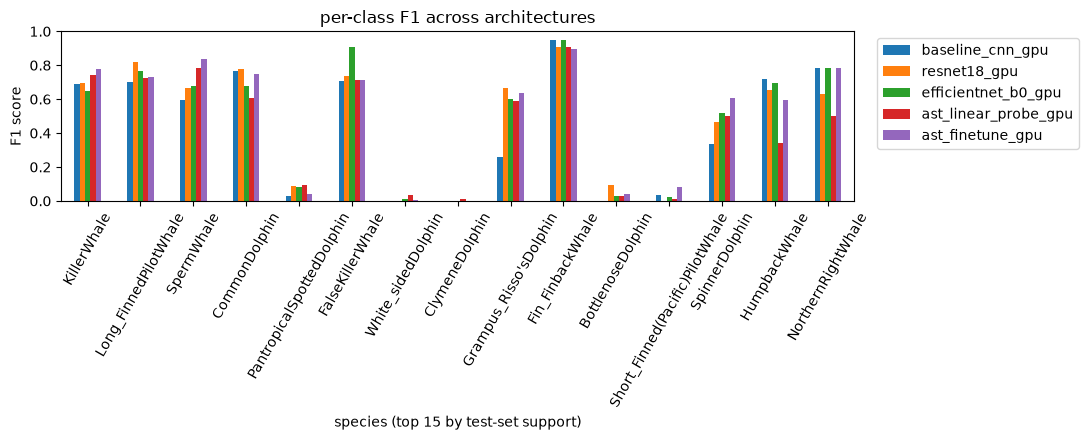

In [5]:
if per_class_df.empty:
    print("No evaluated checkpoints yet -- run the commands from section 1 first.")
else:
    ax = per_class_df.plot(kind="bar", figsize=(11, 4.5))
    ax.set_ylabel("F1 score")
    ax.set_xlabel("species (top 15 by test-set support)")
    ax.set_ylim(0, 1)
    ax.set_title("per-class F1 across architectures")
    ax.tick_params(axis="x", rotation=60)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


A pattern worth specifically checking: is the same species hardest across
every architecture, not just one? If so, that's evidence the difficulty
is in the *data* (few tapes -- see `docs/class_reference.md` -- means
less acoustic variety to learn from) rather than any one model being
weak.

## 3. The leakage gap, at full scale

Notebook 02 demonstrated the leaky-split effect with a 5-epoch, 30%-data
demo. The full-scale version is a genuine train-it-yourself exercise:
this is the one comparison the shipped GPU results *don't* cover, because
every shipped run uses the honest `tape_grouped` split. Train a leaky
counterpart to whichever baseline-CNN run you have, and the cell below
picks it up.

In [6]:
# Pair each honest baseline-CNN run with its leaky counterpart. The GPU run
# is the one that ships, so it's tried first; the CPU-config run is used if
# you trained that instead. Both are tape_grouped -- only the counterpart
# trained with --split-mode clip_random is leaky.
#
# Note the "_full" suffix: notebook 02 already writes a "baseline_cnn_leak_check"
# run at demo scale (5 epochs, 30% subset). Pairing that against a full-scale
# honest run would compare two different training budgets and attribute the
# difference to leakage, so the full-scale leaky run gets its own name.
CANDIDATES = [
    ("baseline_cnn_gpu", "configs/gpu/baseline_cnn.yaml"),
    ("baseline_cnn", "configs/baseline_cnn.yaml"),
]

for honest_name, config_path in CANDIDATES:
    honest_path = RESULTS / "metrics" / f"{honest_name}_eval.json"
    if not honest_path.exists():
        continue
    leak_name = f"{honest_name}_leak_check_full"
    leaky_path = RESULTS / "metrics" / f"{leak_name}_eval.json"
    if not leaky_path.exists():
        print(f"Found the honest run ({honest_name}) but no full-scale leaky counterpart.")
        print(f"  python -m watkins.train --config {config_path} "
              f"--run-name {leak_name} --split-mode clip_random")
        print(f"  python -m watkins.evaluate --checkpoint "
              f"results/checkpoints/{leak_name}_best.pt")
        break

    with open(honest_path) as f:
        honest = json.load(f)
    with open(leaky_path) as f:
        leaky = json.load(f)
    print(f"tape_grouped (honest) split: acc={honest['accuracy']:.3f}  macro_f1={honest['macro_f1']:.3f}")
    print(f"clip_random (leaky) split:   acc={leaky['accuracy']:.3f}  macro_f1={leaky['macro_f1']:.3f}")
    print(f"accuracy inflation from leakage: {leaky['accuracy'] - honest['accuracy']:+.3f}")
    break
else:
    print("No baseline-CNN run found. Train one first, e.g.:")
    print("  python -m watkins.train --config configs/gpu/baseline_cnn.yaml")

Found the honest run (baseline_cnn_gpu) but no full-scale leaky counterpart.
  python -m watkins.train --config configs/gpu/baseline_cnn.yaml --run-name baseline_cnn_gpu_leak_check_full --split-mode clip_random
  python -m watkins.evaluate --checkpoint results/checkpoints/baseline_cnn_gpu_leak_check_full_best.pt


Whatever number you get, that gap is not noise -- it's the same
architecture, same training budget, same everything except which clips
ended up in train vs. test. It's a concrete, measured answer to "how much
should I discount a bioacoustic classification accuracy number if I don't
know how the underlying data was split."

## Exercises

1. Which model has the best macro-F1-per-parameter ratio? Is it the one
   you'd actually deploy if compute/memory were constrained (e.g. an
   edge sensor on a buoy)?
2. Look at each model's confusion matrix figure
   (`results/figures/<run_name>_confusion.png`). Is the *same* species
   pair confused across all four architectures, or does each model have
   its own failure pattern? What would that tell you about whether the
   confusion is a data limitation vs. a model limitation?
3. Repeat the leakage-gap comparison for one more model (e.g. ResNet-18).
   Is the leakage inflation similar in size, or does a bigger/pretrained
   model "exploit" the leaky split more (memorizing tape-specific noise
   floors more easily) than the small baseline CNN?